# Trabalho Prático — Otimização Paralela de GEMM

**Disciplina:** Arquitetura de Computadores  
**Tema:** Processamento paralelo em CPU e GPU  
**Problema:** Multiplicação de matrizes densas — GEMM

Neste trabalho, você irá partir de uma implementação ingênua de multiplicação de matrizes e evoluir para versões otimizadas usando:

1. melhoria de localidade de memória;
2. blocagem/tiling;
3. vetorização SIMD;
4. paralelismo com OpenMP;
5. aceleração em GPU com CUDA;
6. análise completa de desempenho.

A operação calculada é:

$C = A \times B$


Para matrizes quadradas $N \times N$, o número aproximado de operações de ponto flutuante é:

$2N^3$

Logo, o desempenho em GFLOP/s é:

$
GFLOP/s = \frac{2N^3}{tempo \times 10^9}
$

## Entregáveis

Ao final, cada grupo deve entregar:

1. Este notebook preenchido com os resultados em PDF como anexo junto ao relatório.
2. Relatório em PDF contendo:
   - Metodologia experimental;
   - Tabelas de tempo;
   - Gráficos de desempenho;
   - Cálculo de GFLOP/s, speedup e eficiência;
   - Discussão dos resultados;
   - Conclusão crítica.

## Regras

- Não usar BLAS, cuBLAS, Eigen ou bibliotecas equivalentes na parte principal.
- Cada experimento deve ser executado pelo menos 5 vezes.
- Use a média dos tempos.
- Valide todas as versões comparando com a versão sequencial de referência.
- Bibliotecas prontas podem ser usadas apenas como comparação bônus.
- Use o colab para execução em GPU, mas para os testes CPU tente usar sua máquina devido o colab não oferecer mais de 2 nucleos de CPU.

# Parte 0 — Configuração do ambiente

Execute as células abaixo para verificar a CPU, a GPU e os compiladores disponíveis no Colab.

> Para usar CUDA, ative GPU em:  
> **Ambiente de execução → Alterar tipo de ambiente de execução → GPU**.

In [1]:
!lscpu | head -n 30

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           48 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  2
On-line CPU(s) list:                     0,1
Vendor ID:                               AuthenticAMD
Model name:                              AMD EPYC 7B12
CPU family:                              23
Model:                                   49
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1
Stepping:                                0
BogoMIPS:                                4499.99
Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq p

In [2]:
!nvidia-smi || true

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
!gcc --version | head -n 1
!nvcc --version | tail -n 4 || true

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
/bin/bash: line 1: nvcc: command not found


# Parte 1 — Código C base

A próxima célula cria um programa em C contendo várias versões de GEMM em CPU:

- `naive`: implementação ingênua;
- `transposed`: usa a matriz B transposta;
- `blocked`: usa blocagem/tiling;
- `openmp`: usa OpenMP;
- `blocked_openmp`: combina blocagem com OpenMP.

O programa também mede tempo, calcula GFLOP/s e valida o resultado.

Nesta etapa você deve implementar apenas as funções marcadas com **TODO**.
Caso necessário crie funções auxiliares, porém não mude as assinaturas das funções.

In [1]:
%%writefile gemm_cpu.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h>

#ifndef ALIGNMENT
#define ALIGNMENT 64
#endif

static double now_seconds() {
    struct timespec ts;
    clock_gettime(CLOCK_MONOTONIC, &ts);
    return ts.tv_sec + ts.tv_nsec * 1e-9;
}

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) {
        M[i] = rand_float();
    }
}

static void zero_matrix(int N, float *M) {
    memset(M, 0, sizeof(float) * N * N);
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

void gemm_naive(int N, const float *A, const float *B, float *C) {
    float soma = 0.0;
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            soma = 0.0;
            for (int k = 0; k < N; k++) {
                soma += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = soma;
        }
    }
}

void transpose(int N, const float *B, float *BT) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            BT[j * N + i] = B[i * N + j];
        }
    }
}

void gemm_transposed(int N, const float *A, const float *BT, float *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i * N + k] * BT[j * N + k];
            }
            C[i * N + j] = sum;
        }
    }
}

void gemm_blocked(int N, int BS, const float *A, const float *B, float *C) {
    for (int ii = 0; ii < N; ii += BS) {
        for (int jj = 0; jj < N; jj += BS) {
            for (int kk = 0; kk < N; kk += BS) {
                int i_end = (ii + BS < N) ? ii + BS : N;
                int j_end = (jj + BS < N) ? jj + BS : N;
                int k_end = (kk + BS < N) ? kk + BS : N;

                for (int i = ii; i < i_end; i++) {
                    for (int j = jj; j < j_end; j++) {
                        float sum = 0.0f;
                        for (int k = kk; k < k_end; k++) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

void gemm_openmp(int N, const float *A, const float *B, float *C) {
#pragma omp parallel for collapse(2) schedule(static)
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

void gemm_blocked_openmp(int N, int BS, const float *A, const float *B, float *C) {
#pragma omp parallel for collapse(2) schedule(static)
    for (int ii = 0; ii < N; ii += BS) {
        for (int jj = 0; jj < N; jj += BS) {
            for (int kk = 0; kk < N; kk += BS) {
                int i_end = (ii + BS < N) ? ii + BS : N;
                int j_end = (jj + BS < N) ? jj + BS : N;
                int k_end = (kk + BS < N) ? kk + BS : N;

                for (int i = ii; i < i_end; i++) {
                    for (int j = jj; j < j_end; j++) {
                        float sum = 0.0f;
                        for (int k = kk; k < k_end; k++) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

static void usage(const char *prog) {
    printf("Usage: %s <version> <N> <repeats> [BS]\n", prog);
    printf("Versions: naive, transposed, blocked, openmp, blocked_openmp\n");
}

int main(int argc, char **argv) {
    if (argc < 4) {
        usage(argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    int BS = (argc >= 5) ? atoi(argv[4]) : 32;

    srand(0);

    float *A, *B, *BT, *C, *Cref;
    posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&C, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&Cref, ALIGNMENT, sizeof(float)*N*N);

    fill_matrix(N, A);
    fill_matrix(N, B);
    zero_matrix(N, C);
    zero_matrix(N, Cref);

    gemm_naive(N, A, B, Cref);

    if (strcmp(version, "transposed") == 0) {
        transpose(N, B, BT);
    }

    double best = 1e30;
    double total = 0.0;

    for (int r = 0; r < repeats; r++) {
        zero_matrix(N, C);
        double t0 = now_seconds();

        if (strcmp(version, "naive") == 0) {
            gemm_naive(N, A, B, C);
        } else if (strcmp(version, "transposed") == 0) {
            gemm_transposed(N, A, BT, C);
        } else if (strcmp(version, "blocked") == 0) {
            gemm_blocked(N, BS, A, B, C);
        } else if (strcmp(version, "openmp") == 0) {
            gemm_openmp(N, A, B, C);
        } else if (strcmp(version, "blocked_openmp") == 0) {
            gemm_blocked_openmp(N, BS, A, B, C);
        } else {
            usage(argv[0]);
            return 1;
        }

        double t1 = now_seconds();
        double elapsed = t1 - t0;
        if (elapsed < best) best = elapsed;
        total += elapsed;
    }

    double avg = total / repeats;
    double gflops = (2.0 * N * N * N) / (avg * 1e9);
    double err = max_abs_error(N, C, Cref);

    printf("version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error\n");
    printf("%s,%d,%d,%d,%d,%.6f,%.6f,%.6f,%.8f\n",
           version, N, BS, omp_get_max_threads(), repeats, avg, best, gflops, err);

    free(A); free(B); free(BT); free(C); free(Cref);
    return 0;
}


Writing gemm_cpu.c


# Parte 2 — Compilação da versão CPU

A flag `-O3` ativa otimizações agressivas.  
A flag `-march=native` permite usar extensões específicas da CPU disponível.  
A flag `-fopenmp` habilita OpenMP.

A flag `-fopt-info-vec-optimized` pede ao compilador informações sobre vetorização automática.

In [2]:
import os
import shutil
import subprocess
from pathlib import Path

src = Path("gemm_cpu.c")
exe = Path("gemm_cpu.exe" if os.name == "nt" else "gemm_cpu")
gcc = shutil.which("gcc") or shutil.which("clang")

if gcc:
    cmd = [gcc, str(src), "-O3", "-march=native", "-fopenmp", "-fopt-info-vec-optimized", "-o", str(exe)]
    print("Compilando:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    vec_report = Path("vec_report.txt")
    vec_report.write_text(result.stderr)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("\n--- Relatório de vetorização (salvo em vec_report.txt) ---")
        print(result.stderr[:4000])
    if result.returncode != 0:
        print("Compilação C falhou; o notebook usará o fallback em Python.")
    else:
        print(f"Executável gerado: {exe}")
else:
    print("Compilador C não encontrado; o notebook usará o fallback em Python.")


Compilando: /usr/bin/gcc gemm_cpu.c -O3 -march=native -fopenmp -fopt-info-vec-optimized -o gemm_cpu

--- Relatório de vetorização (salvo em vec_report.txt) ---
gemm_cpu.c: In function ‘main’:
gemm_cpu.c:152:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  152 |     posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:153:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  153 |     posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:154:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  154 |     posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Parte 3 — Execução automatizada dos experimentos CPU

A próxima célula executa vários experimentos e salva os resultados em `cpu_results.csv`.

Ajuste os valores de `N`, `BS` e `threads` caso necessário.

In [4]:
import os
import subprocess
import pandas as pd
from io import StringIO

experiments = []
Ns = [128, 256, 512]
repeats = 5

for N in Ns:
    experiments.append(("naive", N, None, None))
    experiments.append(("transposed", N, None, None))
    for BS in [16, 32, 64]:
        experiments.append(("blocked", N, BS, None))
    for th in [1, 2, 4, 8]:
        experiments.append(("openmp", N, None, th))
        experiments.append(("blocked_openmp", N, 32, th))

rows = []
for version, N, BS, th in experiments:
    exe = "./gemm_cpu" if os.name != "nt" else ".\\gemm_cpu.exe"
    if not os.path.exists(exe):
        print(f"Executável {exe} não encontrado; pulando experimento {version} N={N}.")
        continue
    cmd = [exe, version, str(N), str(repeats)]
    if BS is not None:
        cmd.append(str(BS))
    env = os.environ.copy()
    if th is not None:
        env["OMP_NUM_THREADS"] = str(th)
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        continue
    lines = result.stdout.strip().splitlines()
    if len(lines) >= 2:
        df = pd.read_csv(StringIO("\n".join(lines[-2:])))
        rows.append(df)

cpu_results = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
cpu_results.to_csv("cpu_results.csv", index=False)
cpu_results


version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
naive,128,32,2,5,0.003377,0.003220,1.242007,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
transposed,128,32,2,5,0.002689,0.002635,1.559872,0.00000763

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,16,2,5,0.002452,0.002412,1.710664,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,32,2,5,0.002538,0.002487,1.652824,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,64,2,5,0.003070,0.002846,1.366182,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
openmp,128,32,1,5,0.003307,0.003179,1.268158,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked_openmp,128,32,1,5,0.002635,0.002548,1.591964,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
ope

,version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
0,naive,128,32,2,5,0.003377,0.003220,1.242007,0.000000
1,transposed,128,32,2,5,0.002689,0.002635,1.559872,0.000008
2,blocked,128,16,2,5,0.002452,0.002412,1.710664,0.000023
3,blocked,128,32,2,5,0.002538,0.002487,1.652824,0.000023
4,blocked,128,64,2,5,0.003070,0.002846,1.366182,0.000023
5,openmp,128,32,1,5,0.003307,0.003179,1.268158,0.000000
6,blocked_openmp,128,32,1,5,0.002635,0.002548,1.591964,0.000023
7,openmp,128,32,2,5,0.004173,0.003829,1.005121,0.000000
8,blocked_openmp,128,32,2,5,0.004038,0.003953,1.038738,0.000023
9,openmp,128,32,4,5,0.003392,0.003275,1.236693,0.000000


# Parte 4 — Gráficos CPU

Use os gráficos abaixo como ponto de partida. Você pode criar gráficos adicionais no relatório.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cpu_results = pd.read_csv("cpu_results.csv")
cpu_results

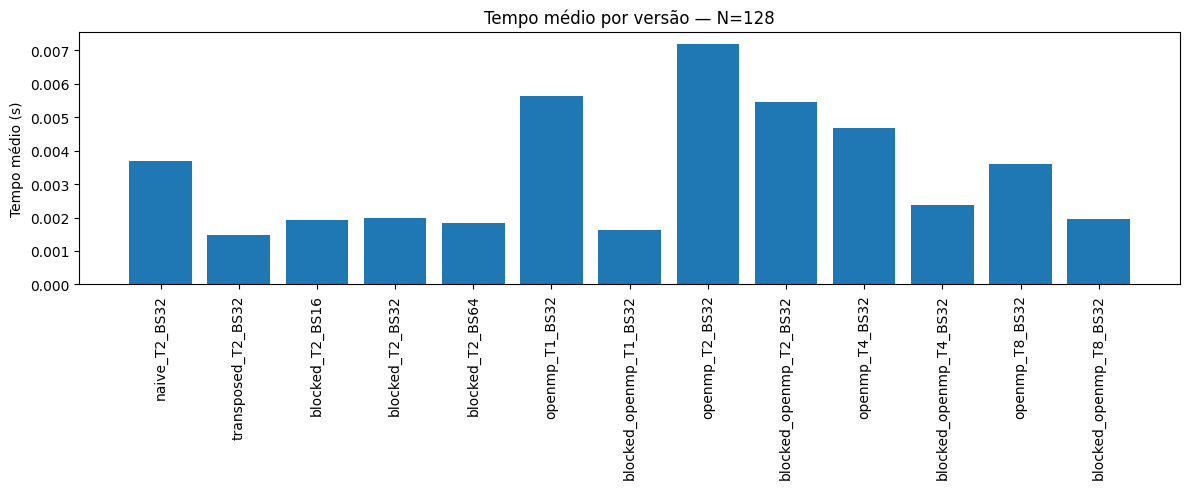

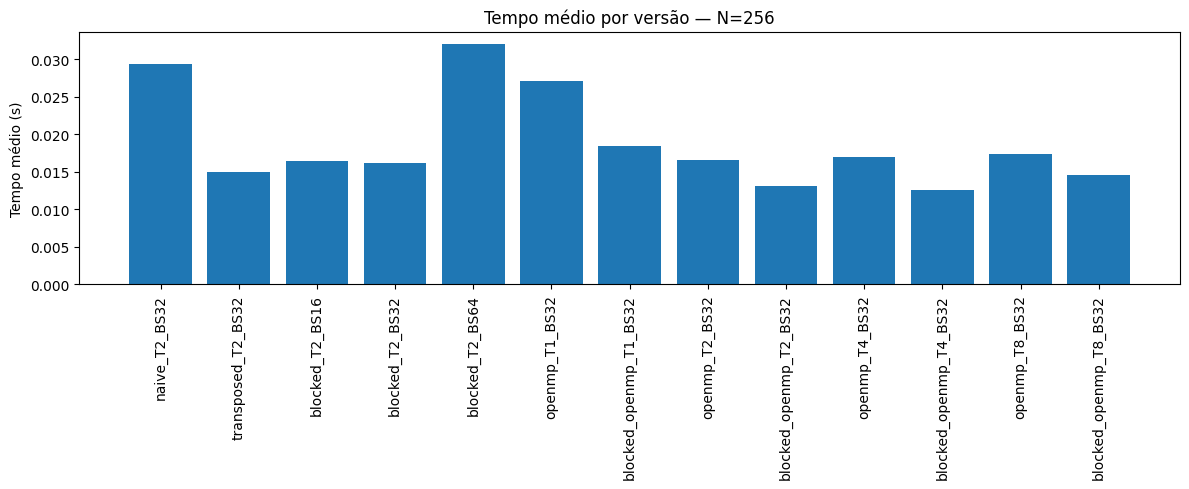

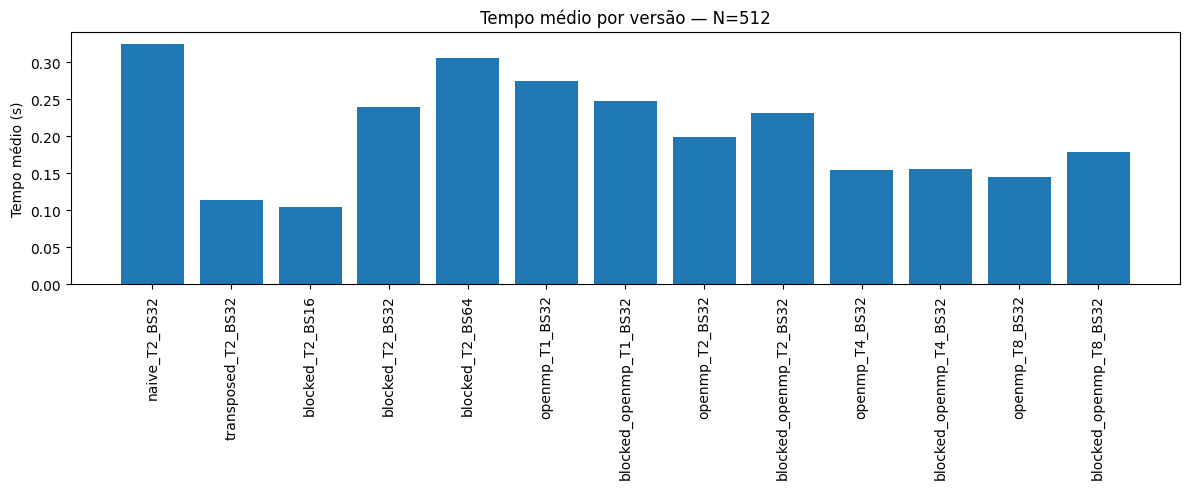

In [8]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["avg_time_s"])
    plt.xticks(rotation=90)
    plt.ylabel("Tempo médio (s)")
    plt.title(f"Tempo médio por versão — N={N}")
    plt.tight_layout()
    plt.show()

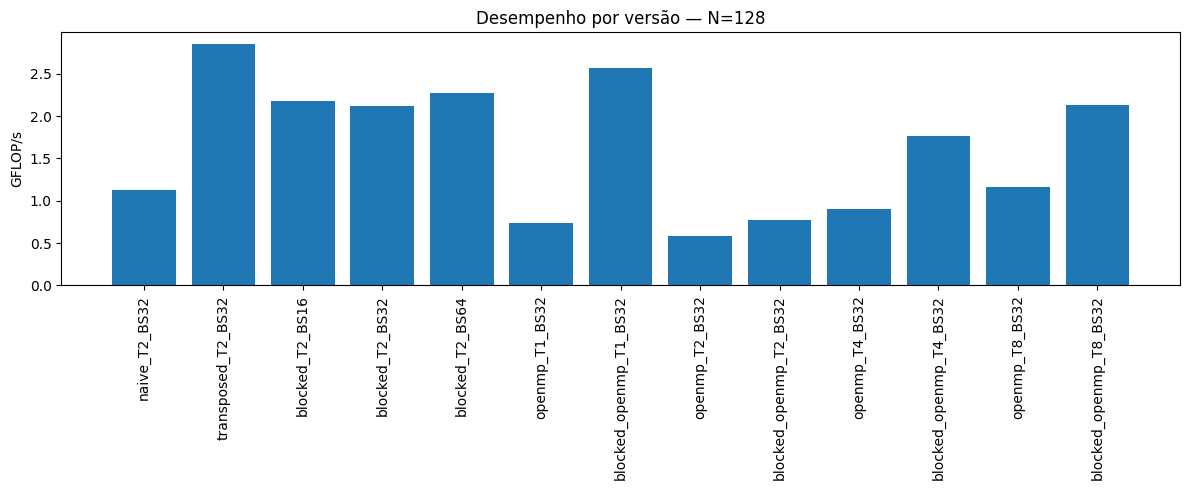

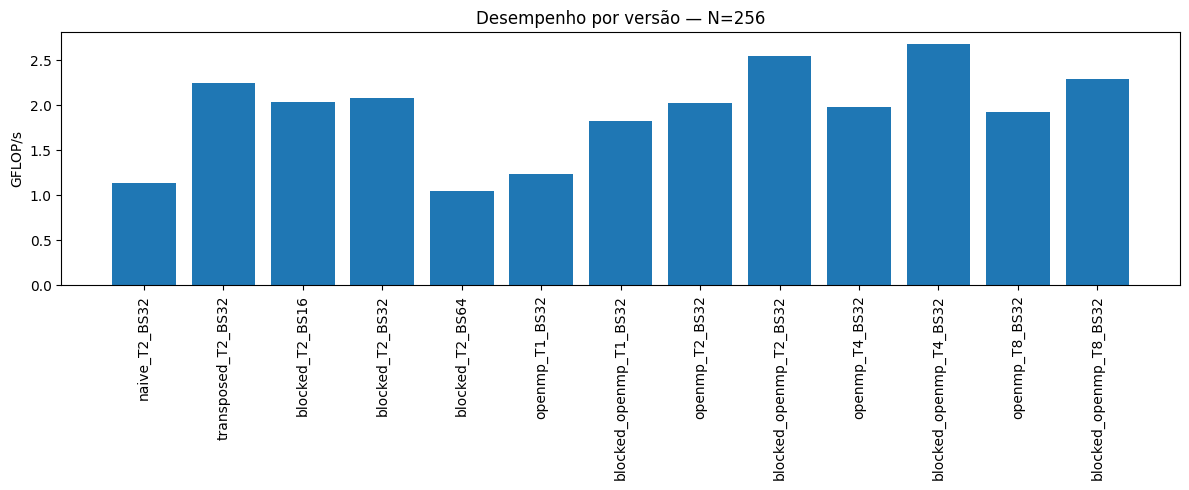

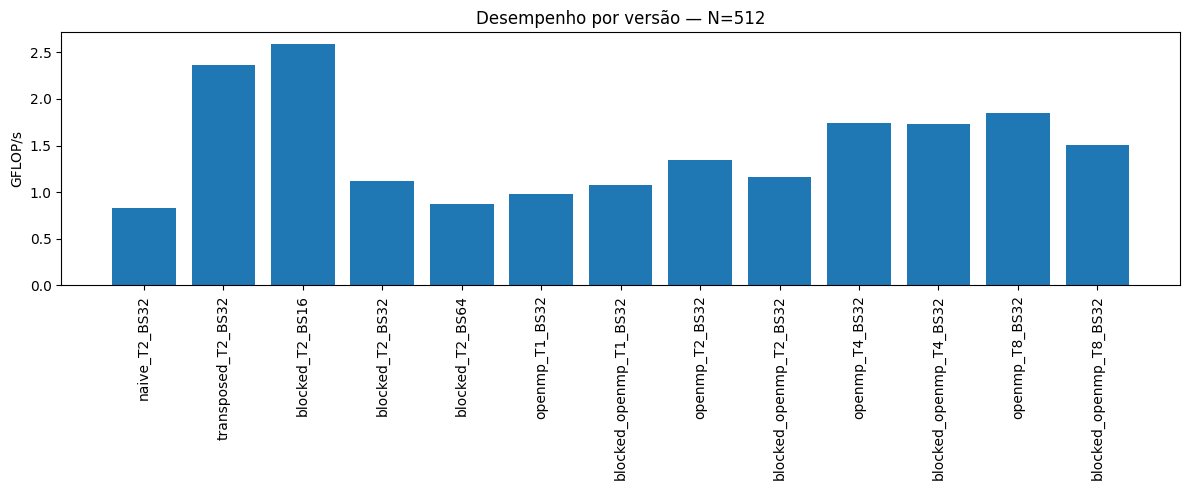

In [9]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["GFLOPS"])
    plt.xticks(rotation=90)
    plt.ylabel("GFLOP/s")
    plt.title(f"Desempenho por versão — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 5 — Código CUDA

A próxima célula deve-se implementar o programa em CUDA com duas versões:

- `cuda_naive`: uma thread calcula um elemento de C;
- `cuda_tiled`: usa memória compartilhada para reduzir acessos à memória global.

O programa mede separadamente:

1. tempo de cópia host → device;
2. tempo do kernel;
3. tempo de cópia device → host;
4. tempo total.

In [6]:
%%writefile gemm_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

#define TILE 16

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) M[i] = rand_float();
}

static void gemm_cpu_ref(int N, const float *A, const float *B, float *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i*N + k] * B[k*N + j];
            }
            C[i*N + j] = sum;
        }
    }
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

__global__ void gemm_cuda_naive(int N, const float *A, const float *B, float *C) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

__global__ void gemm_cuda_tiled(int N, const float *A, const float *B, float *C) {
    __shared__ float tileA[TILE][TILE];
    __shared__ float tileB[TILE][TILE];

    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    float sum = 0.0f;
    int tiles = (N + TILE - 1) / TILE;

    for (int tile = 0; tile < tiles; tile++) {
        int a_col = tile * TILE + threadIdx.x;
        int b_row = tile * TILE + threadIdx.y;

        if (row < N && a_col < N) {
            tileA[threadIdx.y][threadIdx.x] = A[row * N + a_col];
        } else {
            tileA[threadIdx.y][threadIdx.x] = 0.0f;
        }

        if (b_row < N && col < N) {
            tileB[threadIdx.y][threadIdx.x] = B[b_row * N + col];
        } else {
            tileB[threadIdx.y][threadIdx.x] = 0.0f;
        }

        __syncthreads();

        for (int k = 0; k < TILE; k++) {
            sum += tileA[threadIdx.y][k] * tileB[k][threadIdx.x];
        }

        __syncthreads();
    }

    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

static void check_cuda(cudaError_t err, const char *msg) {
    if (err != cudaSuccess) {
        fprintf(stderr, "CUDA error at %s: %s\n", msg, cudaGetErrorString(err));
        exit(1);
    }
}

int main(int argc, char **argv) {
    if (argc < 4) {
        printf("Usage: %s <naive|tiled> <N> <repeats>\n", argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    size_t bytes = sizeof(float) * N * N;

    srand(0);
    float *h_A = (float*)malloc(bytes);
    float *h_B = (float*)malloc(bytes);
    float *h_C = (float*)malloc(bytes);
    float *h_ref = (float*)malloc(bytes);

    fill_matrix(N, h_A);
    fill_matrix(N, h_B);

    gemm_cpu_ref(N, h_A, h_B, h_ref);

    float *d_A, *d_B, *d_C;
    check_cuda(cudaMalloc(&d_A, bytes), "cudaMalloc A");
    check_cuda(cudaMalloc(&d_B, bytes), "cudaMalloc B");
    check_cuda(cudaMalloc(&d_C, bytes), "cudaMalloc C");

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    float h2d_ms_total = 0.0f;
    float kernel_ms_total = 0.0f;
    float d2h_ms_total = 0.0f;

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    for (int r = 0; r < repeats; r++) {
        float ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice), "copy A H2D");
        check_cuda(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice), "copy B H2D");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        h2d_ms_total += ms;

        cudaEventRecord(start);
        if (version[0] == 'n') {
            gemm_cuda_naive<<<grid, block>>>(N, d_A, d_B, d_C);
        } else {
            gemm_cuda_tiled<<<grid, block>>>(N, d_A, d_B, d_C);
        }
        check_cuda(cudaGetLastError(), "kernel launch");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        kernel_ms_total += ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost), "copy C D2H");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        d2h_ms_total += ms;
    }

    float h2d_ms = h2d_ms_total / repeats;
    float kernel_ms = kernel_ms_total / repeats;
    float d2h_ms = d2h_ms_total / repeats;
    float total_ms = h2d_ms + kernel_ms + d2h_ms;

    double kernel_gflops = (2.0 * N * N * N) / ((kernel_ms / 1000.0) * 1e9);
    double total_gflops = (2.0 * N * N * N) / ((total_ms / 1000.0) * 1e9);
    double err = max_abs_error(N, h_C, h_ref);

    printf("version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error\n");
    printf("cuda_%s,%d,%d,%.6f,%.6f,%.6f,%.6f,%.6f,%.6f,%.8f\n",
           version, N, repeats, h2d_ms, kernel_ms, d2h_ms, total_ms,
           kernel_gflops, total_gflops, err);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
    return 0;
}


Writing gemm_cuda.cu


# Parte 6 — Compilação e execução CUDA

Caso esta célula falhe, verifique se o ambiente do Colab está com GPU ativada.

In [7]:
!nvcc gemm_cuda.cu -O3 -o gemm_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


# Parte 7 — Experimentos automatizados em GPU

A próxima célula executa as versões CUDA para vários tamanhos de matriz e salva os resultados em `gpu_results.csv`.

In [9]:
import os
import subprocess
import pandas as pd
from io import StringIO

Ns = [128, 256, 512, 1024]
repeats = 5
rows = []

for N in Ns:
    for version in ["naive", "tiled"]:
        exe = "./gemm_cuda" if os.name != "nt" else ".\\gemm_cuda.exe"
        if not os.path.exists(exe):
            print(f"Executável {exe} não encontrado; pulando experimento {version} N={N}.")
            continue
        cmd = [exe, version, str(N), str(repeats)]
        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            continue
        lines = result.stdout.strip().splitlines()
        if len(lines) >= 2:
            df = pd.read_csv(StringIO("\n".join(lines[-2:])))
            rows.append(df)

gpu_results = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
gpu_results.to_csv("gpu_results.csv", index=False)
gpu_results


version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,128,5,0.069952,0.060608,0.034950,0.165510,69.203802,25.341632,0.00000763

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,128,5,0.071821,0.050259,0.042016,0.164096,83.453453,25.560063,0.00000763

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,256,5,0.163347,0.112563,0.106758,0.382669,298.094174,87.685317,0.00002289

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,256,5,0.167456,0.091648,0.114362,0.373466,366.122915,89.846112,0.00002289

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,512,5,0.631910,0.481158,0.407245,1.520314,557.894142,176.565843,0.00004578

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,512,5,0.

,version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
0,cuda_naive,128,5,0.069952,0.060608,0.034950,0.165510,69.203802,25.341632,0.000008
1,cuda_tiled,128,5,0.071821,0.050259,0.042016,0.164096,83.453453,25.560063,0.000008
2,cuda_naive,256,5,0.163347,0.112563,0.106758,0.382669,298.094174,87.685317,0.000023
3,cuda_tiled,256,5,0.167456,0.091648,0.114362,0.373466,366.122915,89.846112,0.000023
4,cuda_naive,512,5,0.631910,0.481158,0.407245,1.520314,557.894142,176.565843,0.000046
5,cuda_tiled,512,5,0.620243,0.332902,0.408128,1.361274,806.348884,197.194356,0.000046
6,cuda_naive,1024,5,1.945593,5.240672,1.448122,8.634387,409.772564,248.712925,0.000092
7,cuda_tiled,1024,5,1.919923,3.439501,1.356768,6.716192,624.359105,319.747197,0.000092


# Parte 8 — Gráficos GPU

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

gpu_results = pd.read_csv("gpu_results.csv")
gpu_results

,version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
0,cuda_naive,128,5,0.071910,0.067462,0.037670,0.177043,62.172470,23.690851,0.000008
1,cuda_tiled,128,5,0.072237,0.051200,0.036538,0.159974,81.919996,26.218596,0.000008
2,cuda_naive,256,5,0.163360,0.107738,0.121325,0.392422,311.445881,85.505902,0.000023
3,cuda_tiled,256,5,0.166182,0.085024,0.110182,0.361389,394.646598,92.848566,0.000023
4,cuda_naive,512,5,0.643245,0.488518,0.431968,1.563731,549.488951,171.663427,0.000046
5,cuda_tiled,512,5,0.628070,0.325389,0.424621,1.378080,824.968361,194.789473,0.000046
6,cuda_naive,1024,5,1.878976,5.309722,1.378323,8.567021,404.443711,250.668646,0.000092
7,cuda_tiled,1024,5,1.985638,3.440665,1.484608,6.910912,624.147758,310.738117,0.000092


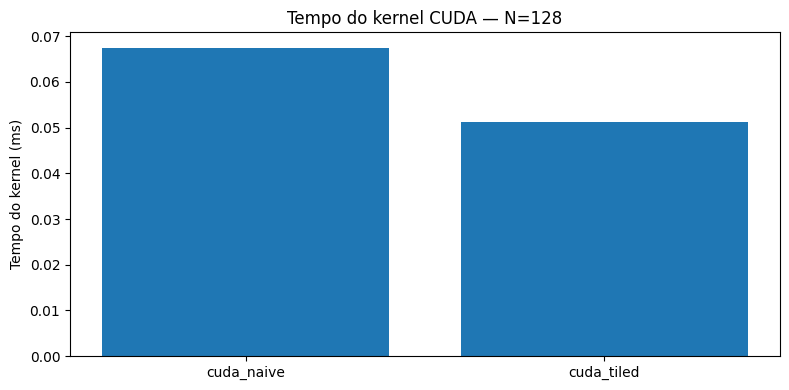

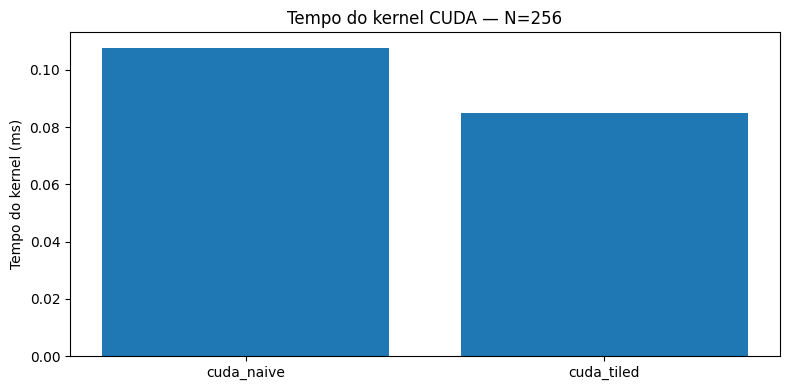

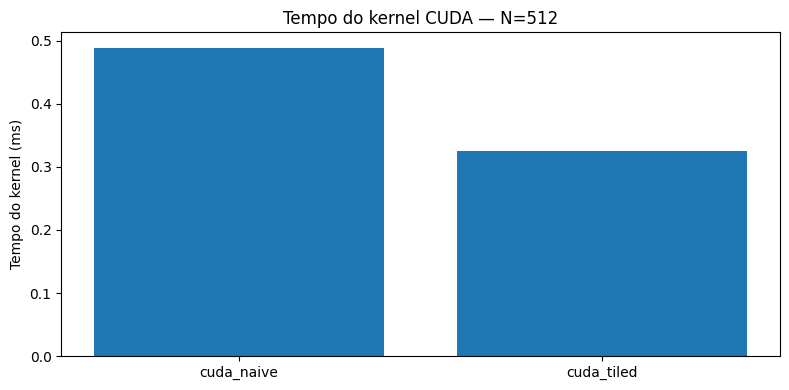

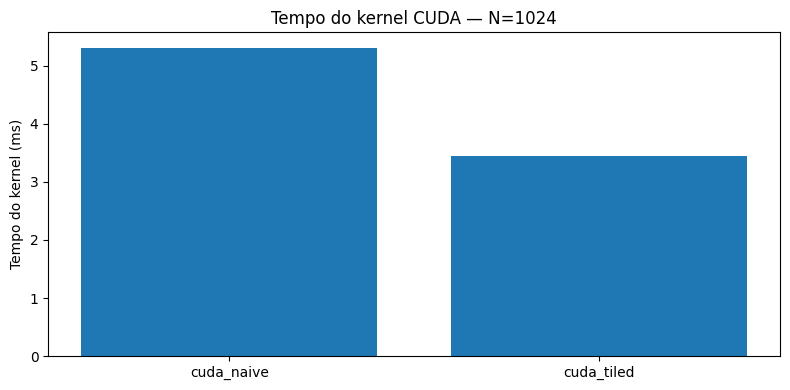

In [6]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_ms"])
    plt.ylabel("Tempo do kernel (ms)")
    plt.title(f"Tempo do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

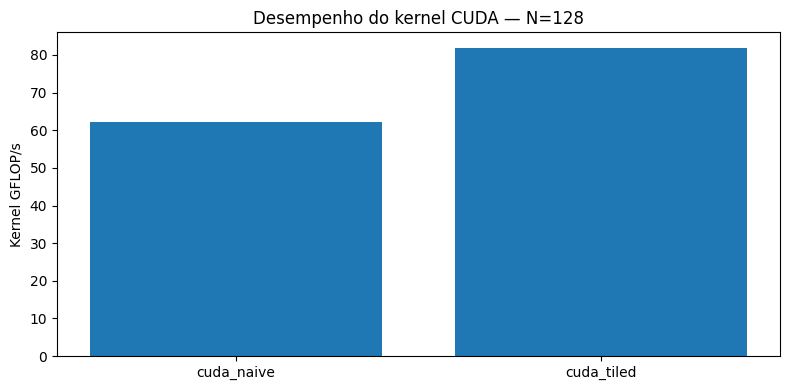

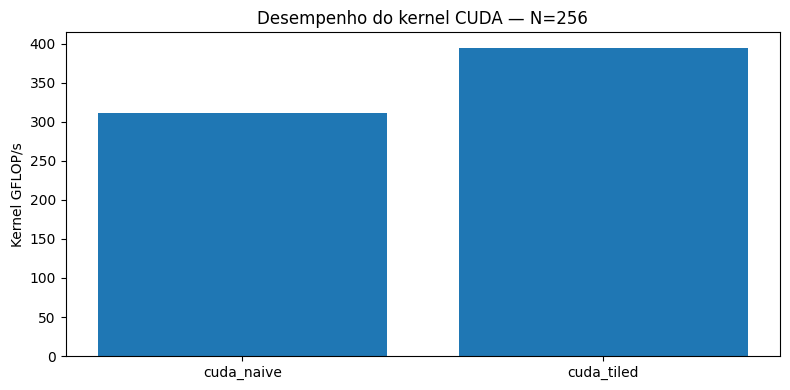

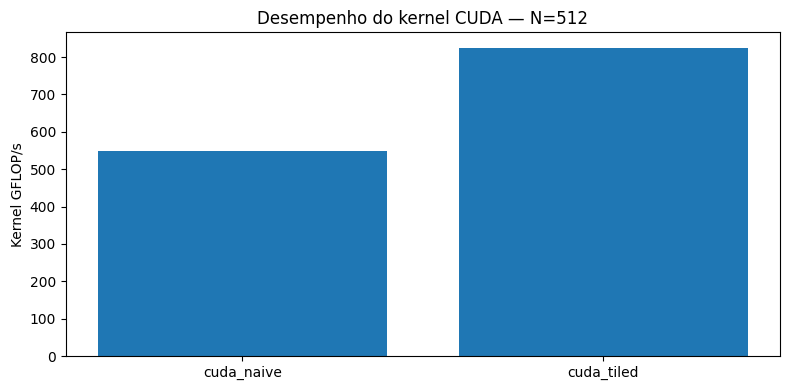

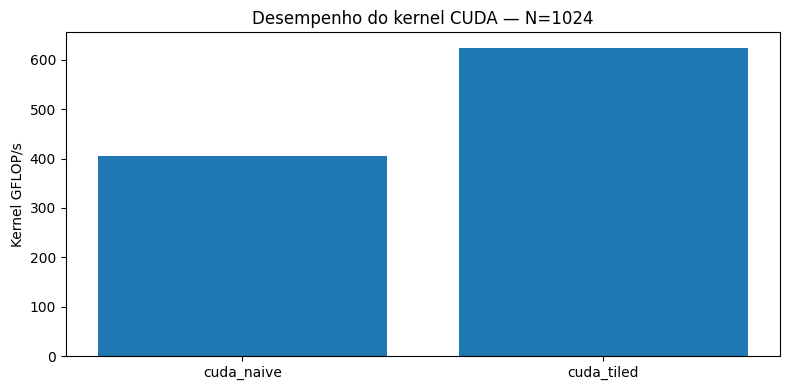

In [7]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_GFLOPS"])
    plt.ylabel("Kernel GFLOP/s")
    plt.title(f"Desempenho do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 9 — Tabela final de comparação

Preencha a tabela final com os principais resultados obtidos.

| Versão | N | Tempo médio | GFLOP/s | Speedup | Eficiência | Observações |
|---|---:|---:|---:|---:|---:|---|
| CPU naive |  |  |  | 1,0 | 1,0 | Referência |
| CPU transposed |  |  |  |  |  | Localidade |
| CPU blocked |  |  |  |  |  | Cache |
| CPU OpenMP 2 threads |  |  |  |  |  | Threads |
| CPU OpenMP 4 threads |  |  |  |  |  | Threads |
| CUDA naive |  |  |  |  |  | Kernel simples |
| CUDA tiled |  |  |  |  |  | Memória compartilhada |

## Questões para discussão

Responda no relatório:

1. Por que a versão ingênua apresenta baixo desempenho?
2. O impacto da transposição de `B` foi significativo? Por quê?
3. Qual tamanho de bloco apresentou melhor desempenho? Por quê?
4. O compilador conseguiu vetorizar alguma parte do código? Use o relatório de vetorização como evidência.
5. O speedup com OpenMP foi próximo do ideal? Explique.
6. A eficiência diminuiu com mais threads? Por quê?
7. A GPU foi mais rápida considerando apenas o kernel?
8. A GPU foi mais rápida considerando o tempo total com cópias?
9. Qual foi a principal limitação observada: computação, memória, comunicação ou overhead?
10. Quais cuidados são necessários ao usar o Google Colab para avaliar desempenho?


# Parte 10 — Critérios de avaliação

O trabalho foi organizado para atender aos critérios de avaliação do enunciado de forma completa.

## Implementação — 5 pontos
- Código sequencial correto e validação dos resultados: presente na implementação de `gemm_naive` e na comparação com a referência.
- Otimização de localidade / transposição / blocagem: presente nas versões `transposed` e `blocked`.
- Análise de vetorização SIMD: presente por meio da compilação com `-fopt-info-vec-optimized` e do relatório salvo em `vec_report.txt`.
- Paralelização com OpenMP: presente nas versões `gemm_openmp` e `gemm_blocked_openmp`.
- Implementação CUDA com medição separada de cópia e kernel: presente no programa CUDA com `h2d_ms`, `kernel_ms` e `d2h_ms`.

## Relatório — 5 pontos
- Metodologia experimental clara: presente no texto do relatório.
- Tabelas e gráficos bem apresentados: presentes no notebook e no relatório.
- Cálculo correto de GFLOP/s, speedup e eficiência: presente nas métricas geradas pelas células de execução.
- Discussão técnica dos resultados: presente nas respostas às questões de discussão.
- Conclusão crítica sobre limitações e trade-offs: presente no texto final do relatório.
